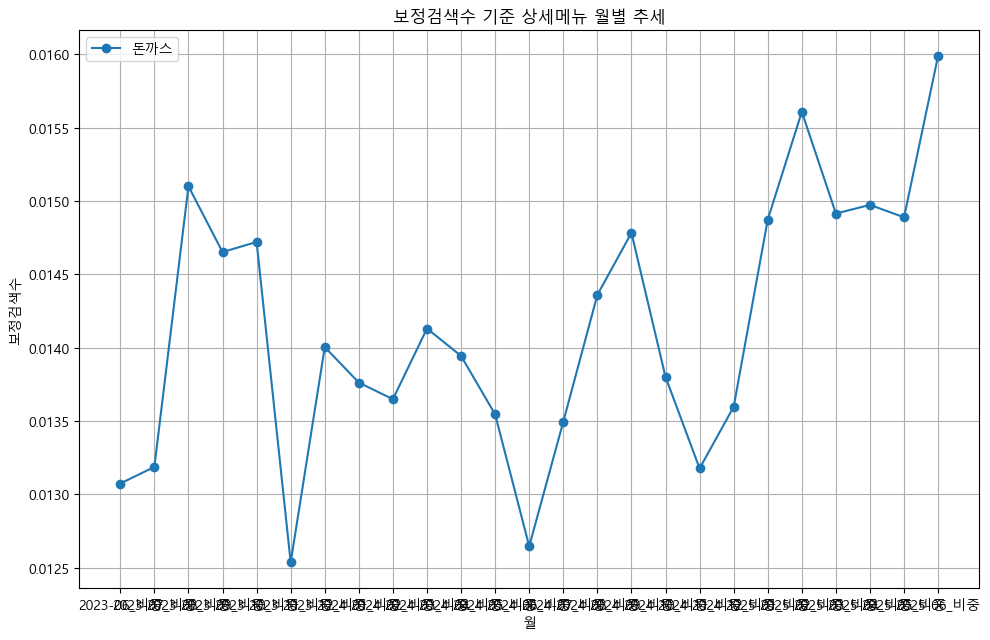

In [17]:
import os
import pandas as pd
import tkinter as tk
from tkinter import messagebox
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# --- 한글 폰트 설정 ---
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# --- URL 기반 데이터 수집 함수 ---
def collect_url_data(folder_path):
    excel_files = [f for f in os.listdir(folder_path) if f.endswith(".xlsx")]
    all_data = pd.DataFrame()
    for file in excel_files:
        try:
            digits = ''.join(filter(str.isdigit, os.path.splitext(file)[0]))
            ym_str = None
            for i in range(len(digits) - 5):
                seg = digits[i:i+6]
                if seg.startswith("20"):
                    ym_str = f"{seg[:4]}-{seg[4:]}"
                    break
            if not ym_str:
                continue
            path = os.path.join(folder_path, file)
            df = pd.read_excel(path, sheet_name="요약", dtype=str)
            url_col = next((col for col in df.columns if '비중반영' in col and 'URL수' in col), None)
            if not url_col or '메뉴' not in df.columns:
                continue
            df = df[['메뉴', url_col]].copy()
            df[url_col] = pd.to_numeric(df[url_col], errors='coerce')
            df['월'] = ym_str
            df = df.rename(columns={url_col: '비중반영_URL수'})
            all_data = pd.concat([all_data, df], ignore_index=True)
        except Exception as e:
            print(f"오류 in {file}: {e}")
    return all_data

# --- 검색 수 기반 데이터 수집 함수 (검색수/보정검색수 분리) ---
def collect_search_data(filepath):
    df = pd.read_excel(filepath, dtype=str)
    col_range = df.columns.tolist()
    # 정확히 25개씩 추출 (열 인덱스 확인됨)
    month_cols_search = col_range[9:34]   # J(9) ~ AH(33)
    month_cols_adjust = col_range[34:59]  # AI(34) ~ BG(58)

    df_search = df[['상세메뉴'] + month_cols_search].copy()
    df_adjust = df[['상세메뉴'] + month_cols_adjust].copy()

    for col in month_cols_search:
        df_search[col] = pd.to_numeric(df_search[col], errors='coerce')
    for col in month_cols_adjust:
        df_adjust[col] = pd.to_numeric(df_adjust[col], errors='coerce')

    df_search['평균'] = df_search[month_cols_search].mean(axis=1)
    df_adjust['평균'] = df_adjust[month_cols_adjust].mean(axis=1)

    df_sorted_search = df_search.sort_values(by='평균', ascending=False).dropna(subset=['상세메뉴'])
    df_sorted_adjust = df_adjust.sort_values(by='평균', ascending=False).dropna(subset=['상세메뉴'])

    return df_sorted_search, month_cols_search, df_sorted_adjust, month_cols_adjust

# --- 통합 Tkinter UI 구성 ---
def create_combined_interface():
    url_folder = r"C:\ksmindpks\ai_x\source\Pks_Develop\N시기별음식URL수집\N월별조회메뉴수집_비중반영"
    search_path = r"C:\ksmindpks\ai_x\source\Pks_Develop\N시기별음식URL수집\상세메뉴_보정결과_비중포함_순서유지.xlsx"

    if not os.path.exists(url_folder) or not os.path.exists(search_path):
        print("지정된 경로가 유효하지 않습니다.")
        return

    url_data = collect_url_data(url_folder)
    pivot_df = url_data.pivot_table(index='메뉴', columns='월', values='비중반영_URL수')
    variation = pivot_df.max(axis=1) - pivot_df.min(axis=1)
    variation_sorted = variation.sort_values(ascending=False)

    df_search, cols_search, df_adjust, cols_adjust = collect_search_data(search_path)

    root = tk.Tk()
    root.title("상세메뉴 URL수 및 검색수 추세 시각화")

    left_frame = tk.Frame(root)
    left_frame.pack(side='left', fill='y', padx=10, pady=10)

    tk.Label(left_frame, text="URL수 변동 Top 메뉴 (최대 5개)").pack()
    lb_url = tk.Listbox(left_frame, selectmode=tk.MULTIPLE, width=40, height=10)
    for menu in variation_sorted.index:
        lb_url.insert(tk.END, menu)
    lb_url.pack(pady=5)

    tk.Label(left_frame, text="검색수 평균 Top 상세메뉴 (최대 5개)").pack(pady=(10, 0))
    lb_search = tk.Listbox(left_frame, selectmode=tk.MULTIPLE, width=40, height=10)
    for menu in df_search['상세메뉴']:
        lb_search.insert(tk.END, menu)
    lb_search.pack(pady=5)

    tk.Label(left_frame, text="보정검색수 Top 상세메뉴 (최대 5개)").pack(pady=(10, 0))
    lb_adjust = tk.Listbox(left_frame, selectmode=tk.MULTIPLE, width=40, height=10)
    for menu in df_adjust['상세메뉴']:
        lb_adjust.insert(tk.END, menu)
    lb_adjust.pack(pady=5)

    btn_frame = tk.Frame(left_frame)
    btn_frame.pack(pady=10)

    graph_frame = tk.Frame(root)
    graph_frame.pack(side='right', fill='both', expand=True, padx=10, pady=10)

    fig, ax = plt.subplots(figsize=(10, 6))
    canvas = FigureCanvasTkAgg(fig, master=graph_frame)
    canvas.get_tk_widget().pack(fill="both", expand=True)

    def plot_trend(lb, df, cols, title, ylabel):
        selected = lb.curselection()
        if len(selected) == 0 or len(selected) > 5:
            messagebox.showwarning("선택 오류", f"{title} 메뉴는 1~5개 선택하세요.")
            return
        selected_menus = [lb.get(i) for i in selected]
        df_selected = df[df[df.columns[0]].isin(selected_menus)].set_index(df.columns[0])
        df_plot = df_selected[cols].T
        ax.clear()
        for menu in df_plot.columns:
            ax.plot(df_plot.index, df_plot[menu], label=menu, marker='o')
        ax.set_title(title)
        ax.set_xlabel("월")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        canvas.draw()

    tk.Button(btn_frame, text="URL수 추세 보기",
              command=lambda: plot_trend(lb_url, pivot_df.reset_index(), pivot_df.columns.tolist(), "URL수 기준 상세메뉴 월별 추세", "비중반영_URL수")).pack(side='left', padx=3)
    tk.Button(btn_frame, text="검색수 추세 보기",
              command=lambda: plot_trend(lb_search, df_search, cols_search, "검색수 기준 상세메뉴 월별 추세", "검색수")).pack(side='left', padx=3)
    tk.Button(btn_frame, text="보정검색수 추세 보기",
              command=lambda: plot_trend(lb_adjust, df_adjust, cols_adjust, "보정검색수 기준 상세메뉴 월별 추세", "보정검색수")).pack(side='left', padx=3)

    root.mainloop()

# 실행
create_combined_interface()